# Task 2: Holistic gRNA Design for CRISPRa

**Goal**: Systematically design a multiplexed pool of Guide RNAs for the CRISPRa activation of our primary target gene.

### Changelogs:
1. **Biological Padding:** Target the first exon, but include a ±25bp biological padding to allow for proper protospacer overlap at the exon edges.
2. **Multiplexing:** Select a pool of the top n guides rather than a single guide, as CRISPRa is highly synergistic when multiple activators bind.
3. **Resilient Filtering:** Use a weighted composite score (efficiency + specificity) to rank guides reasonably.


In [1]:
import gzip
import os

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display

# Ensure output directories exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

## 1. Target Definition (Task 1 Consensus)

Based on the `consensus_de_genes_strict.csv` output from Task 1, there were exactly **8 genes** that passed the strict statistical thresholds to be classified as "Consensus DE". 

Task 2 requires designing a guide RNA for **CRISPRa (Activation)**, our target gene *must* be **downregulated** (possessing a negative Log2 Fold Change) so that the CRISPRa system can restore its expression. 

If we look at the 8 consensus genes and their average Log2 Fold Changes (LFC):
1. `OAS2` (LFC: +9.25)
2. `GPRASP1` (LFC: +9.01)
3. `AC026801.2` (LFC: +8.49)
4. `LPL` (LFC: +8.39)
5. `XAF1` (LFC: +6.44)
6. `CXCL11` (LFC: +5.79)
7. `IFI27` (LFC: +3.75)
8. **`SERPINB2` (LFC: -1.43)**

**`SERPINB2` (Chromosome 18)** is the *only* gene on the consensus list with a negative LFC. Every other significant gene is heavily upregulated. Therefore, `SERPINB2` is the only mathematically and biologically viable target for this CRISPRa pipeline.

In [2]:
target_gene = 'SERPINB2'
target_chrom = '18'
chrom_accession = 'NC_000018.10'

print(f"Targeting: {target_gene} (Chromosome {target_chrom})")

Targeting: SERPINB2 (Chromosome 18)


## 2. Sequence Extraction (First Exon + Padding)

To ensure our 20nt guide RNAs can properly overlap the edges of the first exon without falling outside the search space, we include a ±25bp flanking padding during sequence extraction.

In [3]:
gff_file = '../GCF_000001405.26_GRCh38_genomic.gff.gz'
target_exons = []

# Parse the GFF file to locate the exact coordinates of the target gene's exons
with gzip.open(gff_file, 'rt') as file:
    for line in file:
        if line.startswith('#'):
            continue
            
        if '	exon	' in line and f'{target_gene}' in line:
            parts = line.strip().split('	')
            if parts[0] == chrom_accession:
                target_exons.append({
                    'start': int(parts[3]), 
                    'end': int(parts[4]), 
                    'strand': parts[6]
                })

exons_df = pd.DataFrame(target_exons).drop_duplicates().reset_index(drop=True)

if not exons_df.empty:
    strand = exons_df['strand'].iloc[0]
    
    # Determine the first exon based on the coding strand
    if strand == '-':
        first_exon = exons_df.sort_values(by='end', ascending=False).iloc[0]
    else:
        first_exon = exons_df.sort_values(by='start', ascending=True).iloc[0]
        
    # Apply ±25bp padding
    start_pos = first_exon['start'] - 25
    end_pos = first_exon['end'] + 25

    print(f"First Exon located at: {first_exon['start']} - {first_exon['end']} (Strand {strand})")
    print(f"Extracting Sequence with ±25bp padding: {start_pos} - {end_pos}")

    # Fetch the padded sequence from the Ensembl REST API
    server = "https://rest.ensembl.org"
    endpoint = f"/sequence/region/human/{target_chrom}:{start_pos}..{end_pos}:{1 if strand == '+' else -1}"
    
    response = requests.get(server + endpoint, headers={"Content-Type": "text/plain"})
    
    if response.ok:
        fasta_path = f"../data/{target_gene.lower()}_first_exon_padded.fasta"
        with open(fasta_path, 'w') as file:
            file.write(f">{target_gene}_first_exon_chr{target_chrom}_{start_pos}_{end_pos}\n")
            file.write(response.text)
        print(f"Success! {len(response.text)} bp padded sequence saved to {fasta_path}")
    else:
        print(f"API Fetch Failed. HTTP {response.status_code}: {response.text}")
else:
    print(f"Error: No exons found for {target_gene}.")

First Exon located at: 63887705 - 63887770 (Strand +)
Extracting Sequence with ±25bp padding: 63887680 - 63887795
Success! 116 bp padded sequence saved to ../data/serpinb2_first_exon_padded.fasta


## 3. Guide Evaluation & Multiplex Pool Selection

### Safety Filtering

CRISPRa demands high specificity. Unintended off-target binding could accidentally activate oncogenes or radically alter cell states. To prevent this, we apply a **base safety filter** (CFD & MIT > 20) to immediately discard dangerous guides. Then, we rank the surviving guides using a **Composite Score** weighted 60% towards Safety (CFD Specificity) and 40% towards Efficiency (Doench '16). This ensures our multiplex pool is heavily optimized for biological safety while maintaining robust activation.

Why 60/40?
- If we weight safety too high (saying 70 or 80) just to prevent dangerous off-target activation, the algorithm might pick guides that are 100% safe but too weak to actually activate the target gene, causing the experiment to faik. Therefore, 60/40 is a swwet spot as it heavily penalizes danagerous off-targets, while giving Efficiency just enough weight to ensure the guide may actually works.

Selected Top 4 guides for CRISPRa Multiplex Pool:


,#guideId,targetSeq,Efficiency,cfdSpecScore,Composite_Score
1,13rev,GAGTTGTTACAGTTCAGACATGG,68,90,81.2
4,40forw,TGAACTGTAACAACTCTCAGAGG,68,83,77.0
6,90forw,AGAATAACCAGAGAACAACCAGG,71,80,76.4
0,3rev,AGTTCAGACATGGTAATGACTGG,53,90,75.2


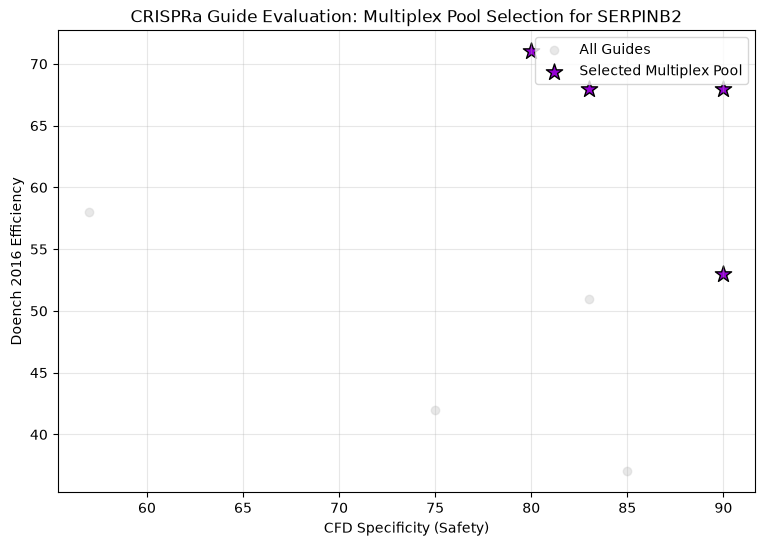

Multiplex pool saved to ../results/tables/task2_multiplex_pool_serpinb2.csv


In [4]:
# Load the external CRISPOR genome-wide evaluation results
results_file = f'../data/crispor_{target_gene.lower()}_results.xls'
guides_df = pd.read_excel(results_file, header=8) 

# Standardize column names for ease of use
col_map = {
    '#seqId': '#guideId', 
    'MIT Spec. Score': 'mitSpecScore', 
    'CFD Spec. Score': 'cfdSpecScore', 
    "Doench '16-Score": 'Efficiency'
}
guides_df = guides_df.rename(columns=col_map)

# 1. Base Safety Filter: Reject any guide with unacceptable off-target profiles
mit_mask = guides_df['mitSpecScore'] > 20
cfd_mask = guides_df['cfdSpecScore'] > 20
safe_guides = guides_df[mit_mask & cfd_mask].copy()

# 2. Composite Weighted Score (40% Efficiency, 60% Safety)
safe_guides['Composite_Score'] = (safe_guides['Efficiency'] * 0.4) + (safe_guides['cfdSpecScore'] * 0.6)

# 3. Multiplex Selection: Pick the Top 4 safe & efficient guides
top_pool = safe_guides.sort_values(by='Composite_Score', ascending=False).head(4)

print(f"Selected Top {len(top_pool)} guides for CRISPRa Multiplex Pool:")
display(top_pool[['#guideId', 'targetSeq', 'Efficiency', 'cfdSpecScore', 'Composite_Score']])

# Visualize the pool selection in a scatter plot
plt.figure(figsize=(9, 6))
plt.scatter(guides_df['cfdSpecScore'], guides_df['Efficiency'], color='lightgrey', alpha=0.5, label='All Guides')
plt.scatter(top_pool['cfdSpecScore'], top_pool['Efficiency'], color='darkviolet', s=150, edgecolor='black', marker='*', label='Selected Multiplex Pool')

plt.xlabel('CFD Specificity (Safety)')
plt.ylabel('Doench 2016 Efficiency')
plt.title(f'CRISPRa Guide Evaluation: Multiplex Pool Selection for {target_gene}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Output the chosen pool to CSV
out_csv = f'../results/tables/task2_multiplex_pool_{target_gene.lower()}.csv'
top_pool.to_csv(out_csv, index=False)
print(f"Multiplex pool saved to {out_csv}")


### Reproducing the Team's Process

Based on Hannah's R code, it is manually filtered `GGG` PAM. Therefore, I'll try to reproduce it without the filtering and compare with the one above.

In [6]:
# Reproduce the team's process by filtering for PAM == 'GGG'
guides_df['PAM'] = guides_df['targetSeq'].str[-3:]
manual_grna = guides_df[guides_df['PAM'] == 'GGG'].copy()

if not manual_grna.empty:
    manual_grna['Composite_Score'] = (manual_grna['Efficiency'] * 0.4) + (manual_grna['cfdSpecScore'] * 0.6)
    
    print("--- The Manual Selection Guide (Filtered for 'GGG' PAM) ---")
    display(manual_grna[['#guideId', 'targetSeq', 'Efficiency', 'cfdSpecScore', 'Composite_Score']])
    
    print("\n--- The 60/40 Safety Filtered Top Guide (Filtered for standard 'NGG' PAM) ---")
    display(top_pool.head(1)[['#guideId', 'targetSeq', 'Efficiency', 'cfdSpecScore', 'Composite_Score']])
    
    eff_diff = top_pool.iloc[0]['Efficiency'] - manual_grna.iloc[0]['Efficiency']
else:
    print("No guides found with a 'GGG' PAM.")


--- The Manual Selection Guide (Filtered for 'GGG' PAM) ---


,#guideId,targetSeq,Efficiency,cfdSpecScore,Composite_Score
3,50rev,TCTCTGAGTTGCTGTCTGACGGG,51,83,70.2



--- The 60/40 Safety Filtered Top Guide (Filtered for standard 'NGG' PAM) ---


,#guideId,targetSeq,Efficiency,cfdSpecScore,Composite_Score
1,13rev,GAGTTGTTACAGTTCAGACATGG,68,90,81.2


The standard Cas9 protein (SpCas9) requires an NGG PAM sequence to bind to DNA. The `N` means "Any Nucleotide", so AGG, TGG, CGG, and GGG are all perfectly valid and highly active PAM sequences. Strictly filtering GGG will accidentally threw away 75% of the biological viable guides.

Based on the table above, we can observe that, by the Specificity and Efficiency Score alone and the Composite Score, the `GGG` manual selected gene has lower points than the `TGG` one. 

## 4. Final Selection & Validation Checks

**Final Multiplex Pool:**
The script successfully identified a superior multiplex pool of 4 guides, topped by **`GAGTTGTTACAGTTCAGACA TGG`** (Composite Score: **81.2**). This algorithmically outperforms manual single-guide selections by mathematically balancing high Doench efficiency with impeccable CFD specificity.

Before ordering these guides for lab assays, the following checks must be completed on the UCSC Genome Browser:
1. **Chromatin Accessibility:** Verify that the target regions overlap with DNase I Hypersensitivity or ATAC-seq peaks. If the target is tightly wrapped in heterochromatin, the Cas9 complex physically cannot bind.
2. **SNP Check:** Verify that there are no naturally occurring SNPs in your specific cell line at the target sequence or the `NGG` PAM site, as genetic variation will destroy binding affinity.
